# Unemployment Analysis with Python

In this notebook I look at monthly unemployment data for Indian states, clean it, and check how Covid-19 and the 2020 lockdown affected unemployment.

Two files are used:
- `Unemployment_in_India.csv` (May 2019 to June 2020, split by rural and urban)
- `Unemployment_Rate_upto_11_2020.csv` (Jan 2020 to Oct 2020, by state and zone)

Both files are in the `data` folder.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Loading the data

In [2]:
df1 = pd.read_csv("data/Unemployment_in_India.csv")
df2 = pd.read_csv("data/Unemployment_Rate_upto_11_2020.csv")

print(df1.shape, df2.shape)

(768, 7) (267, 9)


In [3]:
df1.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
df2.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


## Cleaning

In [5]:
# the column names have extra spaces, so I rename them
df1.columns = ["state", "date", "freq", "rate", "employed", "lpr", "area"]
# (the longitude / latitude headers in this file are swapped, I name them by their values)
df2.columns = ["state", "date", "freq", "rate", "employed", "lpr", "zone", "lat", "lon"]

# df1 has some completely empty rows
print(df1.isnull().sum())
df1 = df1.dropna()
print(df1.shape)

state       28
date        28
freq        28
rate        28
employed    28
lpr         28
area        28
dtype: int64
(740, 7)


In [6]:
# remove extra spaces and convert the dates
for d in [df1, df2]:
    d["state"] = d["state"].str.strip()
    d["date"] = pd.to_datetime(d["date"].str.strip(), dayfirst=True)

df1["area"] = df1["area"].str.strip()

print("duplicates:", df1.duplicated().sum(), df2.duplicated().sum())
print(df1["date"].min(), df1["date"].max())
print(df2["date"].min(), df2["date"].max())

duplicates: 0 0
2019-05-31 00:00:00 2020-06-30 00:00:00
2020-01-31 00:00:00 2020-10-31 00:00:00


## Exploring the data

In [7]:
df1[["rate", "employed", "lpr"]].describe()

,rate,employed,lpr
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [8]:
df2[["rate", "employed", "lpr"]].describe()

,rate,employed,lpr
count,267.000000,2.670000e+02,267.000000
mean,12.236929,1.396211e+07,41.681573
std,10.803283,1.336632e+07,7.845419
min,0.500000,1.175420e+05,16.770000
25%,4.845000,2.838930e+06,37.265000
50%,9.650000,9.732417e+06,40.390000
75%,16.755000,2.187869e+07,44.055000
max,75.850000,5.943376e+07,69.690000


## Unemployment rate over time

The dataset only gives a rate per state, so to get one number for the whole country I work out the labour force and the number of unemployed people in each state, add them up, and divide. This is better than averaging the state rates because big states count more than small ones.

In [9]:
for d in [df1, df2]:
    d["labour_force"] = d["employed"] / (1 - d["rate"] / 100)
    d["unemployed"] = d["labour_force"] - d["employed"]

g1 = df1.groupby("date")[["unemployed", "labour_force"]].sum()
g2 = df2.groupby("date")[["unemployed", "labour_force"]].sum()
rate1 = g1["unemployed"] / g1["labour_force"] * 100
rate2 = g2["unemployed"] / g2["labour_force"] * 100

# first file for 2019, second file from January 2020
national = pd.concat([rate1[rate1.index < "2020-01-01"], rate2])
national.round(2)

date
2019-05-31     7.04
2019-06-30     7.88
2019-07-31     7.37
2019-08-31     8.08
2019-09-30     7.08
2019-10-31     8.11
2019-11-30     7.25
2019-12-31     7.73
2020-01-31     7.22
2020-02-29     7.77
2020-03-31     8.76
2020-04-30    23.95
2020-05-31    21.83
2020-06-30    10.23
2020-07-31     7.43
2020-08-31     8.36
2020-09-30     6.71
2020-10-31     7.01
dtype: float64

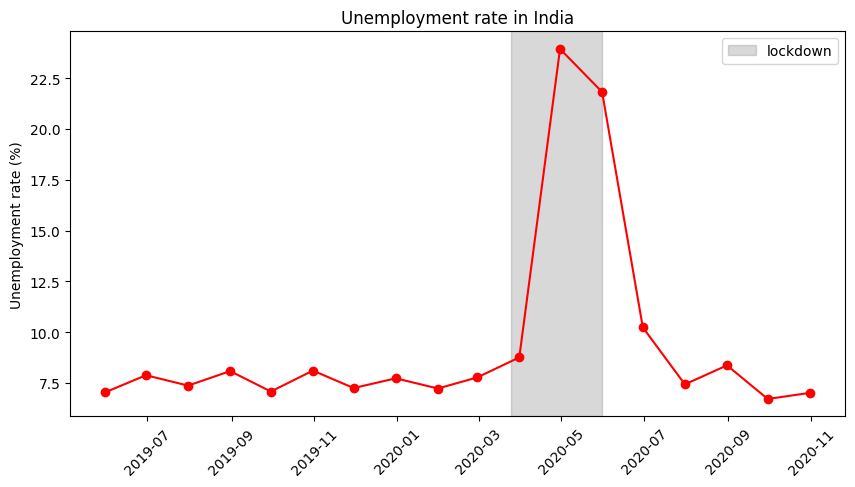

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(national.index, national.values, marker="o", color="red")
plt.axvspan(pd.Timestamp("2020-03-25"), pd.Timestamp("2020-05-31"), color="grey", alpha=0.3, label="lockdown")
plt.title("Unemployment rate in India")
plt.ylabel("Unemployment rate (%)")
plt.xticks(rotation=45)
plt.legend()
plt.show()

## Impact of Covid-19

In [11]:
monthly = df2.groupby("date").agg(employed=("employed", "sum"), lpr=("lpr", "mean"))
monthly["employed_mn"] = monthly["employed"] / 1e6
monthly["rate"] = rate2
monthly[["rate", "employed_mn", "lpr"]].round(2)

,rate,employed_mn,lpr
date,,,
2020-01-31,7.22,406.57,44.63
2020-02-29,7.77,402.69,44.18
2020-03-31,8.76,392.54,43.75
2020-04-30,23.95,274.83,35.30
2020-05-31,21.83,310.70,39.65
2020-06-30,10.23,374.15,41.20
2020-07-31,7.43,389.29,42.27
2020-08-31,8.36,389.58,42.39
2020-09-30,6.71,393.87,41.97


In [12]:
before = monthly.loc["2020-01":"2020-02"]
during = monthly.loc["2020-04":"2020-05"]

print("Average rate Jan-Feb:", round(before["rate"].mean(), 1))
print("Average rate Apr-May:", round(during["rate"].mean(), 1))
print("Peak:", round(monthly["rate"].max(), 1), "in", monthly["rate"].idxmax().strftime("%B %Y"))
print("October 2020:", round(monthly["rate"].iloc[-1], 1))

feb = monthly["employed_mn"].iloc[1]
apr = monthly["employed_mn"].iloc[3]
print("Employed fell by", round(feb - apr), "million from Feb to Apr (", round((feb - apr) / feb * 100), "% )")
print("Participation rate Jan-Feb:", round(before["lpr"].mean(), 1), " Apr-May:", round(during["lpr"].mean(), 1))

Average rate Jan-Feb: 7.5
Average rate Apr-May: 22.9
Peak: 23.9 in April 2020
October 2020: 7.0
Employed fell by 128 million from Feb to Apr ( 32 % )
Participation rate Jan-Feb: 44.4  Apr-May: 37.5


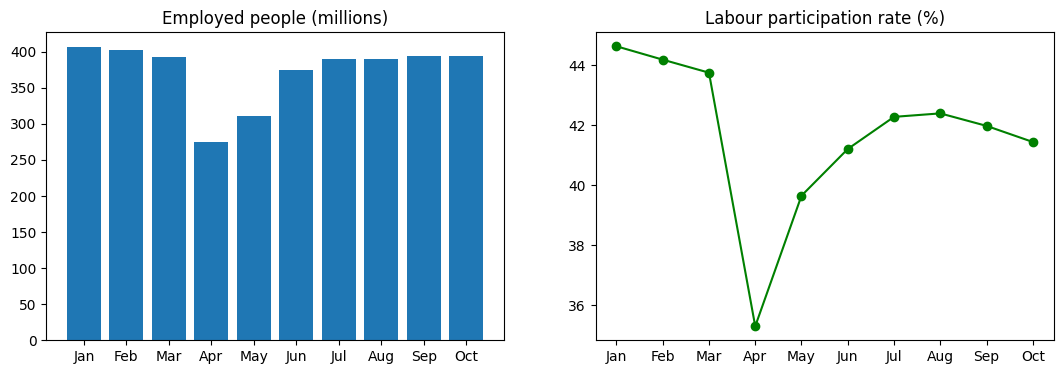

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].bar(monthly.index.strftime("%b"), monthly["employed_mn"])
ax[0].set_title("Employed people (millions)")

ax[1].plot(monthly.index.strftime("%b"), monthly["lpr"], marker="o", color="green")
ax[1].set_title("Labour participation rate (%)")

plt.show()

## Rural vs urban

In [14]:
g = df1.groupby(["date", "area"])[["unemployed", "labour_force"]].sum()
ru = (g["unemployed"] / g["labour_force"] * 100).unstack()
ru.round(2)

area,Rural,Urban
date,,
2019-05-31,6.31,8.59
2019-06-30,7.70,8.25
2019-07-31,6.92,8.34
2019-08-31,7.49,9.35
2019-09-30,5.91,9.57
2019-10-31,8.04,8.25
2019-11-30,6.46,8.90
2019-12-31,7.07,9.05
2020-01-31,6.08,9.72


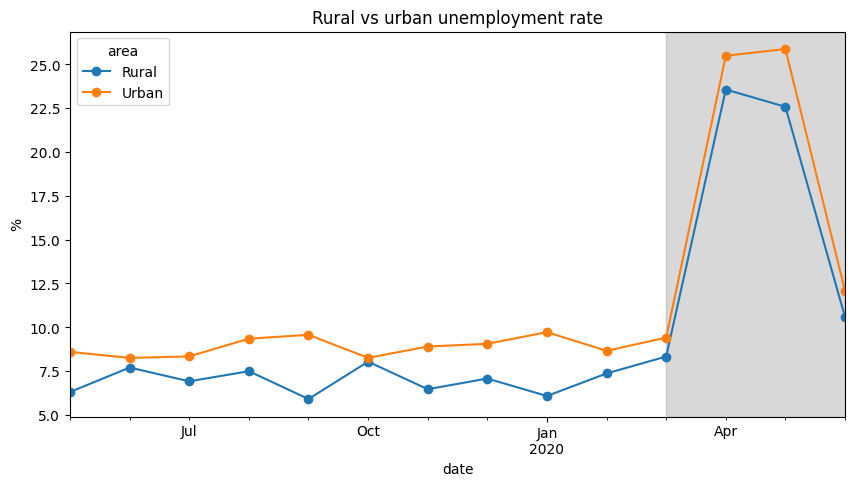

In [15]:
ru.plot(figsize=(10, 5), marker="o")
plt.axvspan(pd.Timestamp("2020-03-25"), pd.Timestamp("2020-06-30"), color="grey", alpha=0.3)
plt.title("Rural vs urban unemployment rate")
plt.ylabel("%")
plt.show()

## States

In [16]:
pivot = df2.pivot_table(index="state", columns="date", values="rate")

before = pivot.iloc[:, 0:2].mean(axis=1)   # Jan and Feb
peak = pivot.iloc[:, 3:5].max(axis=1)      # April and May
jump = (peak - before).sort_values(ascending=False)

top = pd.DataFrame({"before": before, "peak": peak, "october": pivot.iloc[:, -1]})
top["jump"] = jump
top = top.sort_values("jump", ascending=False).head(10)
top.round(1)

,before,peak,october,jump
state,,,,
Puducherry,1.2,75.8,6.2,74.7
Jharkhand,11.2,59.2,11.8,48.0
Tamil Nadu,1.8,49.8,2.2,48.0
Bihar,10.4,46.6,9.8,36.2
Karnataka,3.2,29.8,1.6,26.6
Delhi,18.5,42.3,6.3,23.7
Odisha,2.5,23.8,2.2,21.2
Haryana,23.1,43.2,27.3,20.2
Madhya Pradesh,4.3,22.0,3.1,17.6


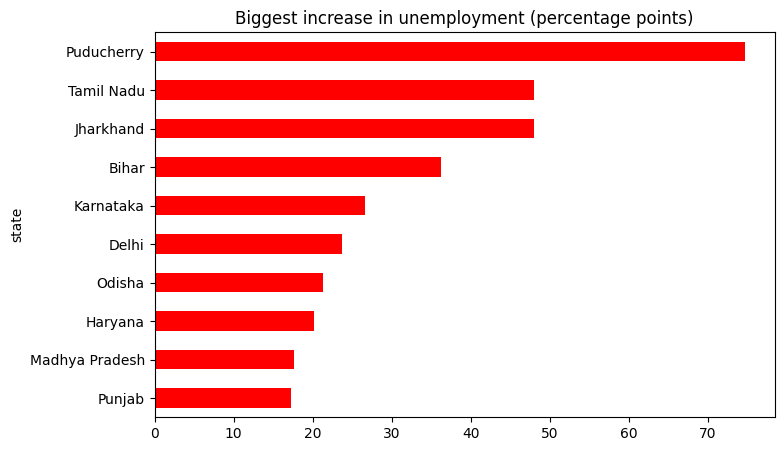

In [17]:
top["jump"].sort_values().plot(kind="barh", figsize=(8, 5), color="red")
plt.title("Biggest increase in unemployment (percentage points)")
plt.show()

## Zones

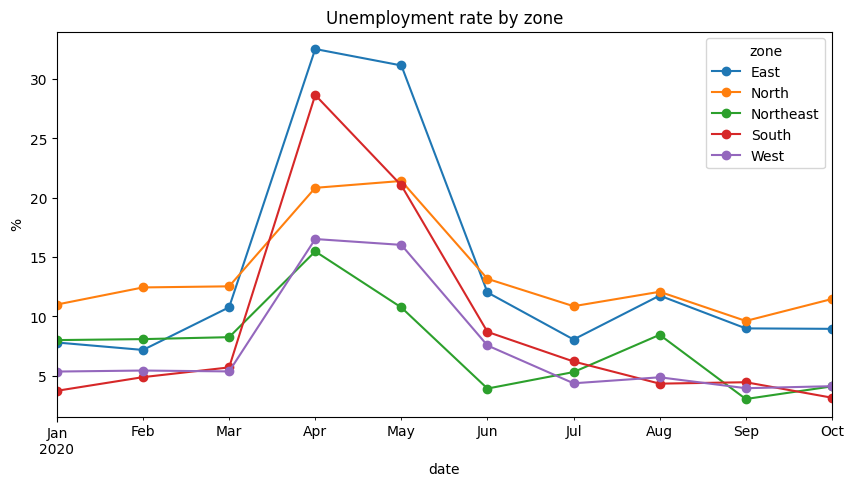

zone,East,North,Northeast,South,West
date,,,,,
2020-01-31,7.8,11.0,8.0,3.7,5.3
2020-02-29,7.2,12.4,8.1,4.9,5.4
2020-03-31,10.8,12.5,8.2,5.7,5.4
2020-04-30,32.5,20.8,15.5,28.6,16.5
2020-05-31,31.1,21.4,10.7,21.0,16.0
2020-06-30,12.0,13.2,3.9,8.7,7.5
2020-07-31,8.0,10.9,5.3,6.2,4.4
2020-08-31,11.7,12.1,8.4,4.3,4.9
2020-09-30,9.0,9.6,3.0,4.4,3.9


In [18]:
g = df2.groupby(["date", "zone"])[["unemployed", "labour_force"]].sum()
zones = (g["unemployed"] / g["labour_force"] * 100).unstack()

zones.plot(figsize=(10, 5), marker="o")
plt.title("Unemployment rate by zone")
plt.ylabel("%")
plt.show()
zones.round(1)

## Seasonal patterns

Before Covid there are only 10 months of data (May 2019 to Feb 2020), so it is hard to say anything about seasonality.

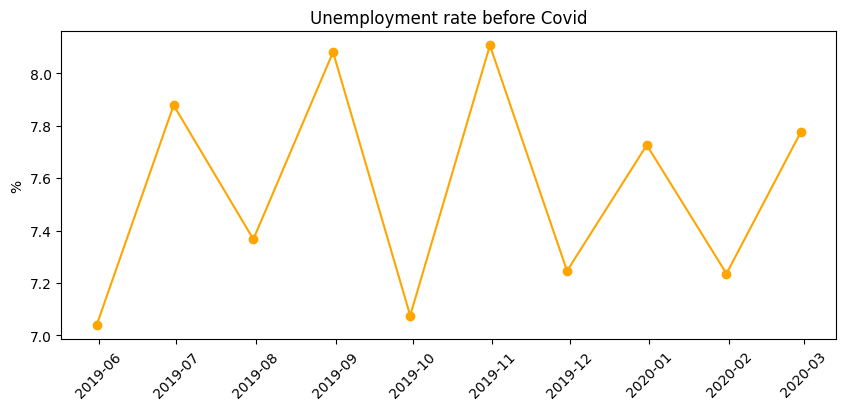

min: 7.0  max: 8.1


In [19]:
pre = rate1[rate1.index < "2020-03-01"]

plt.figure(figsize=(10, 4))
plt.plot(pre.index, pre.values, marker="o", color="orange")
plt.title("Unemployment rate before Covid")
plt.ylabel("%")
plt.xticks(rotation=45)
plt.show()

print("min:", round(pre.min(), 1), " max:", round(pre.max(), 1))

## Conclusions

- Before the lockdown the unemployment rate stayed around 7 to 8% with no clear seasonal pattern. After the lockdown started in late March it jumped to about 24% in April 2020 and was still around 22% in May.
- About 128 million fewer people were employed in April than in February. The participation rate also dropped, which means many people stopped looking for work, so the unemployment rate alone understates the problem.
- By June the rate fell to about 10%, and from July to October it stayed between about 6.7% and 8.4%, close to the level before Covid.
- Urban areas were hit a bit harder than rural areas (about 25 to 26% vs 22 to 24% in April and May) and were slower to recover.
- The East and South zones had the highest rates in April (about 32% and 29%). Some states went up by a huge amount, like Puducherry, Jharkhand, Tamil Nadu and Bihar. A few of these values look extreme (Puducherry went from about 1% to 76%), so they may be affected by small survey samples.

**What this suggests for policy:** workers in the informal sector and in cities need income support when a sudden shutdown happens, rural employment schemes help as a safety net, and relief should be targeted by region because the effect was not the same everywhere. It is also better to follow the participation rate together with the unemployment rate.

**Limitations:** the data covers only about 18 months, so seasonality can't be checked properly, and this analysis shows timing and size of the change but does not prove the cause.